In [ ]:
import torch
from transformers.models.bert import BertModel,BertTokenizer

In [ ]:
model_name = 'bert-base-uncased'

In [ ]:
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name,output_hidden_states = True)

[transformers] loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594/config.json
[transformers] Model config BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "output_hidden_states": true,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.12.1",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

[transformer

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
model.config

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "output_hidden_states": true,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.12.1",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

In [ ]:
model

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

在经典的 Transformer 架构中，每个编码器层（BertLayer）主要由两大块组成：

自注意力机制（Attention）：负责让句子中的词汇互相“关注”，理解上下文（对应图底部的 attention: BertAttention）。

前馈神经网络（FFN）：对注意力层提取到的信息进行深度的非线性变换。

在 Hugging Face 的代码实现中，这个 FFN 被人为拆分成了两个模块：intermediate（中间层）和 output（输出层）。intermediate 就是负责“升维和激活”的第一步。

* BertLayer
    * attention: BertAttention
        * self: BertSelfAttention
        * output: BertSelfOutput
    * intermediate: BertIntermediate, 768=>4\*768
    * output: BertOutput, 4\*768 => 768

In [ ]:
test_sent = 'this is a text sentence'
model_input = tokenizer(test_sent,return_tensors='pt')

In [ ]:
model.eval()
with torch.no_grad():
  output = model(**model_input)

In [ ]:
# 解析：output[2] 代表所有层的隐藏状态 (hidden_states)，
# 它是一个包含 13 个张量的元组 (1层 Embedding + 12层 Transformer)
# ---------------------------------------------------------

# 【提取初始词向量层 (Embeddings)】
# 索引 [0] 取出的是第 0 层的数据。
# 此时的张量仅仅是 Token 经过 Embedding 层转换后的初始向量，
# 还没有经过任何 Transformer 编码器（注意力机制）的处理。
output[2][0]

tensor([[[ 0.1686, -0.2858, -0.3261,  ..., -0.0276,  0.0383,  0.1640],
         [-0.6485,  0.6739, -0.0932,  ...,  0.4475,  0.6696,  0.1820],
         [-0.6270, -0.0633, -0.3143,  ...,  0.3427,  0.4636,  0.4594],
         ...,
         [-0.3106,  0.4050,  0.7143,  ...,  1.1165, -0.1912,  0.8347],
         [ 0.8323,  0.2878,  0.0021,  ...,  0.2628, -1.1310, -1.2708],
         [-0.1481, -0.2948, -0.1690,  ..., -0.5009,  0.2544, -0.0700]]])

In [ ]:
# 【提取第一层 Transformer 输出】
# 索引 [1] 取出的是第 1 层的数据。
# 此时的张量是初始词向量经过了 BERT 第一层 Transformer Block
# （包含自注意力计算和前馈神经网络）深度交互、处理后的隐藏状态特征。
output[2][1]

tensor([[[ 0.1878,  0.0060, -0.0567,  ...,  0.0782,  0.0365,  0.0845],
         [-0.4103,  0.5753,  0.2735,  ...,  0.0797,  0.4148,  0.1099],
         [-1.0588, -0.3630, -0.3623,  ...,  0.1972,  0.1065,  0.4199],
         ...,
         [ 0.4013,  0.6341,  1.0074,  ...,  1.4039, -0.4624,  0.8133],
         [ 1.0452,  0.7742,  0.2803,  ...,  0.3970, -1.0308, -1.2645],
         [-0.0386,  0.0187,  0.0406,  ..., -0.4638,  0.6413,  0.0140]]])

# 源码部分实现

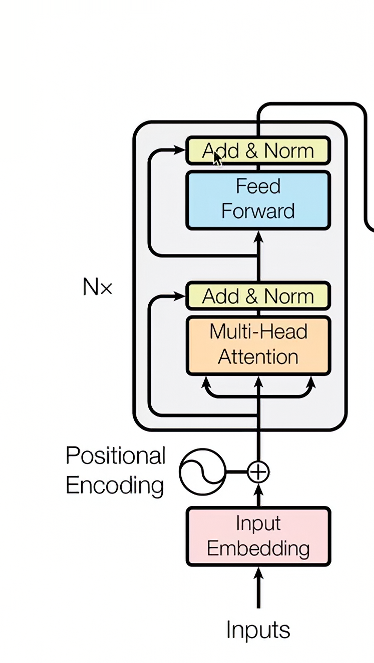

In [ ]:
embeddings = output[2][0]
embeddings

tensor([[[ 0.1686, -0.2858, -0.3261,  ..., -0.0276,  0.0383,  0.1640],
         [-0.6485,  0.6739, -0.0932,  ...,  0.4475,  0.6696,  0.1820],
         [-0.6270, -0.0633, -0.3143,  ...,  0.3427,  0.4636,  0.4594],
         ...,
         [-0.3106,  0.4050,  0.7143,  ...,  1.1165, -0.1912,  0.8347],
         [ 0.8323,  0.2878,  0.0021,  ...,  0.2628, -1.1310, -1.2708],
         [-0.1481, -0.2948, -0.1690,  ..., -0.5009,  0.2544, -0.0700]]])

从模型的网络结构中，把第 1 个 Transformer 编码器层单独“拎”出来，赋值给变量 layer。

In [ ]:
layer = model.encoder.layer[0]

# 开始第一次add&norm，此时发生在mha内部

In [ ]:
mha_output = layer.attention.self(embeddings)
mha_output

(tensor([[[ 0.2956,  0.0858, -0.0062,  ..., -0.0163,  0.1304,  0.0879],
          [ 0.3810,  0.1436, -0.0925,  ...,  0.1309,  0.3256,  0.1959],
          [ 0.1101,  0.1538, -0.0924,  ...,  0.3768,  0.5834,  0.4961],
          ...,
          [-0.0192,  0.1843, -0.1565,  ...,  0.2453,  0.4013,  0.3555],
          [-0.0957,  0.1843, -0.0422,  ...,  0.2239,  0.4471,  0.3153],
          [ 0.2513,  0.1179, -0.1005,  ...,  0.0200,  0.1650,  0.1124]]],
        grad_fn=<ViewBackward0>),
 None)

为什么是 mha_output[0]？（[0] 代表什么）
仔细观察第一段代码的输出结果，你会发现 mha_output 并不是一个单纯的张量（Tensor），而是一个元组（Tuple）：
(tensor([...]), None)

第一个元素 tensor([...])：这是自注意力层真正计算出来的核心特征矩阵。

第二个元素 None：在 Hugging Face 的实现中，自注意力层除了返回特征，通常还可以返回“注意力权重矩阵”（即模型到底把注意力分配给了哪些词）。因为这里可能没有明确要求在此刻输出注意力权重，或者没有传入 attention_mask，所以它默认返回了 None。

因此，mha_output[0] 的作用就是把元组解包，单独提取出里面那个真实的特征张量，丢弃掉后面的 None，以便参与后续的数学运算。

2. 为何要传入两个参数？（核心原理：残差连接）
代码：layer.attention.output(mha_output[0], embeddings)

在 BERT 的结构中，layer.attention.output 这个模块（对应源码中的 BertSelfOutput）主要负责做三件事：线性映射（Dense）、残差连接（Add）、层归一化（Norm）。

之所以要同时传入这两个参数，正是为了完成 残差连接（Add & Norm）：

参数 1：mha_output[0]
这是刚刚经过自注意力机制“深加工”得到的新特征。它包含了词与词之间丰富的上下文关系。

参数 2：embeddings
这是最原始的输入（即还没进注意力层之前的数据）。

内部到底发生了什么？
当你把这两个参数传进去时，layer.attention.output 内部大致执行了以下逻辑（用伪代码表示）：

结果 = LayerNorm( Dropout( Dense(参数1) ) + 参数2 )

In [ ]:
attn_output = layer.attention.output(mha_output[0],embeddings)
attn_output

tensor([[[ 0.6864, -0.1688, -0.4746,  ...,  0.2445,  0.1624,  0.4306],
         [-0.7981,  1.0780, -0.1036,  ...,  0.4830,  1.1305,  0.5302],
         [-0.7037,  0.1218, -0.4667,  ...,  0.3683,  0.4226,  0.8791],
         ...,
         [ 0.3397,  0.4927,  1.0418,  ...,  1.5582, -0.3516,  1.3239],
         [ 1.8579,  0.5078,  0.5115,  ...,  0.6593, -1.4830, -1.5489],
         [ 0.7227, -0.7484, -0.0521,  ..., -0.9767,  0.5070, -0.3247]]],
       grad_fn=<NativeLayerNormBackward0>)

# 发生在mlp中的第一次add&norm

输入：传入的 attn_output 是上一阶段自注意力层（经过了第一次 Add & Norm）输出的结果。

内部操作：这一步调用了 BertIntermediate 模块。它首先通过一个全连接层（Linear）将特征维度从标准的 768 维放大（升维）到 3072 维。接着，使用 GELU 激活函数进行非线性变换。

印证点：输出张量的末尾显示 grad_fn=<GeluBackward0>，这完美证明了在这一步的最后应用了 GELU 激活函数。

In [ ]:
mlpl = layer.intermediate(attn_output)
mlpl

tensor([[[-3.5828e-03, -4.4605e-02, -4.3370e-03,  ..., -2.7379e-02,
          -9.0715e-03, -1.5923e-03],
         [-3.2044e-02, -4.0403e-02, -1.9153e-06,  ..., -2.0951e-03,
          -2.2353e-02, -5.3708e-04],
         [-1.3116e-02, -1.2830e-03, -1.6291e-07,  ..., -3.7754e-04,
          -3.1742e-02, -1.4765e-02],
         ...,
         [-1.1154e-03, -1.6273e-01, -2.2369e-05,  ..., -1.0391e-04,
          -1.2453e-02, -1.2138e-02],
         [-9.7507e-02, -4.6560e-02,  0.0000e+00,  ..., -2.3853e-03,
          -1.3494e-01, -6.1184e-02],
         [-6.1776e-04, -5.2002e-02, -3.0869e-04,  ..., -3.6596e-03,
          -1.5261e-02, -1.6309e-05]]], grad_fn=<GeluBackward0>)

为什么要传入两个参数？

mlp1：是在高维空间（3072维）处理过的新特征。

attn_output：是进入 MLP 之前的原始输入，也就是老特征（残差）。

内部操作：

降维（Dense）：首先把 mlp1 从 3072 维重新压缩回标准的 768 维。

残差相加（Add）：将降维后的新特征与 attn_output（老特征）直接对应元素相加，防止网络过深导致的特征丢失或梯度消失。

层归一化（Norm）：对相加后的结果进行 Layer Normalization。

印证点：输出张量末尾显示 grad_fn=<NativeLayerNormBackward0>，证明这整个流程的最后一步执行的确实是层归一化（Norm）。

In [ ]:
mlpl.shape

torch.Size([1, 7, 3072])

In [ ]:
mlpl2 = layer.output(mlpl,attn_output)
mlpl2

tensor([[[ 0.1878,  0.0060, -0.0567,  ...,  0.0782,  0.0365,  0.0845],
         [-0.4103,  0.5753,  0.2735,  ...,  0.0797,  0.4148,  0.1099],
         [-1.0588, -0.3630, -0.3623,  ...,  0.1972,  0.1065,  0.4199],
         ...,
         [ 0.4013,  0.6341,  1.0074,  ...,  1.4039, -0.4624,  0.8133],
         [ 1.0452,  0.7742,  0.2803,  ...,  0.3970, -1.0308, -1.2645],
         [-0.0386,  0.0187,  0.0406,  ..., -0.4638,  0.6413,  0.0140]]],
       grad_fn=<NativeLayerNormBackward0>)